## Formatting

In [14]:
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import MultipleLocator
#import cmasher as cmr
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
from datetime import timedelta
from datetime import date
from usos_dictionaries import voc_available_days_dict

import IPython
notebook_name = "/".join(
        IPython.extract_module_locals()[1]["__vsc_ipynb_file__"].split("/")[-5:]
    )

#region: Plot formatting
mpl.rcParams['xtick.labelsize'] = 15
mpl.rcParams['ytick.labelsize'] = 15
mpl.rcParams['legend.fontsize'] = 15
mpl.rcParams['axes.labelsize'] = 18
mpl.rcParams['axes.titlesize'] = 24
mpl.rcParams['axes.xmargin'] = 0

# Set the font family to 'serif'
mpl.rcParams['font.family'] = 'serif'
# Specify preferred serif font (Computer Modern Roman is 'cmr10')
mpl.rcParams['font.serif'] = 'Lato' 
# Optionally, configure mathtext to use Computer Modern fonts as well
mpl.rcParams['mathtext.fontset'] = 'cm'
# Ensure minus signs are rendered correctly with CM fonts
mpl.rcParams['axes.unicode_minus'] = False

#Colorblind friendly colors in RGB:
forest_green_color = np.array([51,117,56])
bright_green_color = np.array([51, 117, 56])
indigo_color = np.array([46, 37, 133])
bright_blue_color = np.array([0, 114, 178])
light_blue_color = np.array([86, 180, 233])
pale_blue_color = np.array([148, 203, 236])
yellow_orange_color = np.array([230, 159, 0])
sunny_yellow_color = np.array([230, 159, 20])
lemon_yellow_color = np.array([240, 228, 66])
bright_orange_color = np.array([235, 97, 35])
desaturated_pink_color = np.array([194, 106, 119])
purple_pink = np.array([204, 121, 167])
saturated_orchid_color = np.array([194, 106, 119])
purple_orchid_color = np.array([159, 74, 150])
bright_purple_color = np.array([81, 40, 136])
turquoise_color = np.array([64, 176, 166])
dark_blue_color = np.array([13, 64, 165])
dark_teal = np.array([0, 102, 102])
rich_orange = np.array([230, 120, 20])


def rgb_range_correction(color_names):
    mpl_formatted_colors = []
    for c in range(0,len(color_names)):
        rgb_division = color_names[c]/255
        mpl_formatted_colors.append(rgb_division)
    return mpl_formatted_colors

four_colorset1 = rgb_range_correction([pale_blue_color, dark_teal, rich_orange, desaturated_pink_color])

#endregion

## Loading files

In [2]:
#read YAML files
dirpath = '/uufs/chpc.utah.edu/common/home/haskins-group1/users/vsun/USOS_shared/'

run_number = '1'
mech_name = ['CB6r5h', 'CRACMM', 'GEOS-Chem']#, 'MCM']
start_date = date(2024, 7, 19)
end_date   = date(2024, 8, 12)

df_CB6r5h_species_conc = pd.DataFrame()
df_CRACMM_species_conc = pd.DataFrame()
df_GEOSChem_species_conc = pd.DataFrame()
# df_MCM_species_conc = pd.DataFrame()

df_CB6r5h_analysis = pd.DataFrame()
df_CRACMM_analysis = pd.DataFrame()
df_GEOSChem_analysis = pd.DataFrame()

for mech in mech_name:
    date_count = start_date
    while date_count <= end_date:
        print(date_count)
        run_month = date_count.month
        run_day  = date_count.day
        run_date = str(run_month) + '_' + str(run_day) + '_' + '2024'
        yaml_usos_dirpath = dirpath + 'F0AM-4.4.2/Runs/USOS_' + run_date
        yaml_usos_full_filepath_species_conc = yaml_usos_dirpath + '/' + 'Run' + run_number + '/' + mech +'/USOS_' + run_date + '_' + mech + '_' + 'Run' + run_number + '_species_conc_output' + '.yaml'
        print('Processing file: ', yaml_usos_full_filepath_species_conc)
        with open(yaml_usos_full_filepath_species_conc, 'r') as f:
            yaml_usos_species_conc = yaml.full_load(f)
        # with open(yaml_usos_full_filepath_analysis, 'r') as f:
        #     yaml_usos_analysis = yaml.full_load(f)

        processed_data_species_conc = {k: [item[0] if isinstance(item, list) else item for item in v] for k, v in yaml_usos_species_conc.items()}
        df_yaml_species_conc = pd.DataFrame(processed_data_species_conc)
        
        if mech == 'CB6r5h':
            df_CB6r5h_species_conc = pd.concat([df_CB6r5h_species_conc, df_yaml_species_conc], ignore_index=True)
        #     print(df_CB6r5h_analysis)
        #     print(df_yaml_analysis)
        #     df_CB6r5h_analysis = pd.concat([df_CB6r5h_analysis, df_yaml_analysis], ignore_index=True)
        elif mech == 'CRACMM':
            df_CRACMM_species_conc = pd.concat([df_CRACMM_species_conc, df_yaml_species_conc], ignore_index=True)
        #     print(df_CRACMM_analysis)
        #     #print(df_yaml_analysis)
        #     #df_CRACMM_analysis = pd.concat([df_CRACMM_analysis, df_yaml_analysis], ignore_index=True)

        elif mech == 'GEOS-Chem':
            df_GEOSChem_species_conc = pd.concat([df_GEOSChem_species_conc, df_yaml_species_conc], ignore_index=True)
        #     print(df_GEOSChem_analysis)
        #     #df_GEOSChem_analysis = pd.concat([df_GEOSChem_analysis, df_yaml_analysis], ignore_index=True)
        elif mech == 'MCM':
            df_MCM_species_conc = pd.concat([df_MCM_species_conc, df_yaml_species_conc], ignore_index=True)
        #     print(df_MCM_analysis)
        #     #df_MCM_analysis = pd.concat([df_MCM_analysis, df_yaml_analysis], ignore_index=True)
        else:
            print('Mechanism name invalid')
        
        date_count += timedelta(days=1)

new_start_time = pd.Timestamp('2024-07-19 00:00:00')
new_end_time = pd.Timestamp('2024-08-12 23:45:00')
#Create a new datetime index from new_start to the end of existing index with same frequency
new_index = pd.date_range(start=new_start_time, end=new_end_time, freq='15min', tz = 'America/Denver')
print(new_index)

df_CB6r5h_hrly_species_conc = df_CB6r5h_species_conc.copy()
df_CRACMM_hrly_species_conc = df_CRACMM_species_conc.copy()
print(df_CRACMM_hrly_species_conc)
df_GEOSChem_hrly_species_conc = df_GEOSChem_species_conc.copy()
# df_MCM_hrly_species_conc = df_MCM_species_conc.copy()

df_CB6r5h_hrly_species_conc.set_index(new_index, inplace=True)
df_CRACMM_hrly_species_conc.set_index(new_index, inplace=True)
df_GEOSChem_hrly_species_conc.set_index(new_index, inplace=True)
# df_MCM_hrly_species_conc.set_index(new_index, inplace=True)

hour_range = np.arange(0,24,1)

2024-07-19
Processing file:  /uufs/chpc.utah.edu/common/home/haskins-group1/users/vsun/USOS_shared/F0AM-4.4.2/Runs/USOS_7_19_2024/Run1/CB6r5h/USOS_7_19_2024_CB6r5h_Run1_species_conc_output.yaml
2024-07-20
Processing file:  /uufs/chpc.utah.edu/common/home/haskins-group1/users/vsun/USOS_shared/F0AM-4.4.2/Runs/USOS_7_20_2024/Run1/CB6r5h/USOS_7_20_2024_CB6r5h_Run1_species_conc_output.yaml
2024-07-21
Processing file:  /uufs/chpc.utah.edu/common/home/haskins-group1/users/vsun/USOS_shared/F0AM-4.4.2/Runs/USOS_7_21_2024/Run1/CB6r5h/USOS_7_21_2024_CB6r5h_Run1_species_conc_output.yaml
2024-07-22
Processing file:  /uufs/chpc.utah.edu/common/home/haskins-group1/users/vsun/USOS_shared/F0AM-4.4.2/Runs/USOS_7_22_2024/Run1/CB6r5h/USOS_7_22_2024_CB6r5h_Run1_species_conc_output.yaml
2024-07-23
Processing file:  /uufs/chpc.utah.edu/common/home/haskins-group1/users/vsun/USOS_shared/F0AM-4.4.2/Runs/USOS_7_23_2024/Run1/CB6r5h/USOS_7_23_2024_CB6r5h_Run1_species_conc_output.yaml
2024-07-24
Processing file:  /

In [3]:
df_CB6r5h_species_conc.set_index(new_index, inplace=True)
df_CRACMM_species_conc.set_index(new_index, inplace=True)
df_GEOSChem_species_conc.set_index(new_index, inplace=True)

## Plotting functions

In [4]:
exceedance_date_list = voc_available_days_dict['Exceedance_days']

[41.037      37.35833333 39.25577778 36.02422222 34.19733333 32.092
 29.57       26.72477778 28.44677778 36.44511111 46.21955556 52.204
 55.51311111 57.38522222 60.64833333 62.16433333 62.069      61.47933333
 58.50693273 55.19966667 47.60984483 45.23222222 46.31433333 43.71477778]


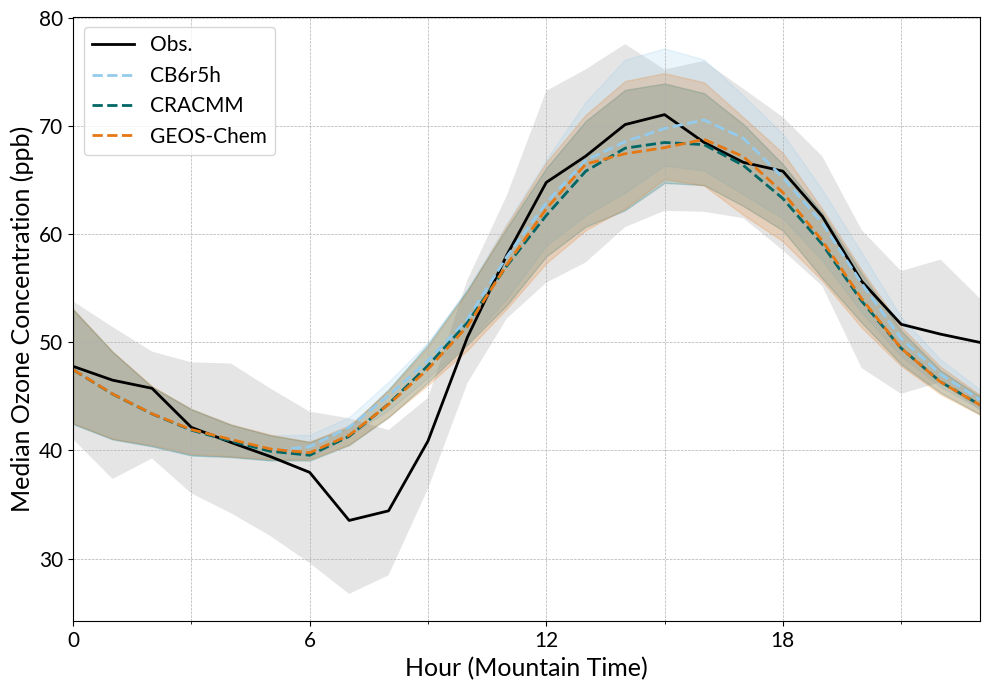

In [24]:
def plot_ozone_hourly_median():
    #Put data into hour-of-day bin
    df_CB6r5h_hrly_species_conc['hour'] = df_CB6r5h_hrly_species_conc.index.hour
    df_CRACMM_hrly_species_conc['hour'] = df_CRACMM_hrly_species_conc.index.hour
    df_GEOSChem_hrly_species_conc['hour'] = df_GEOSChem_hrly_species_conc.index.hour
    # df_MCM_hrly_species_conc['hour'] = df_MCM_hrly_species_conc.index.hour

    #Group by hour and take mean per species
    df_CB6r5h_hourly_medians_species_conc = df_CB6r5h_hrly_species_conc.groupby('hour').median()
    df_CRACMM_hourly_medians_species_conc = df_CRACMM_hrly_species_conc.groupby('hour').median()
    df_GEOSChem_hourly_medians_species_conc = df_GEOSChem_hrly_species_conc.groupby('hour').median()
    #df_MCM_hourly_medians_species_conc = df_MCM_hrly_species_conc.groupby('hour').median()

    # fig, (ax1, ax2) = plt.subplots(2,1, figsize = (16,8), tight_layout=True)
    fig, ax = plt.subplots(figsize = (10,7), layout = 'tight')

    plt.plot(hour_range, df_CB6r5h_hourly_medians_species_conc['O3Initconc'], label = 'Obs.', linestyle = 'solid', linewidth = 2, color = 'k')
    obs_percentile_25_ozone=df_CB6r5h_hrly_species_conc.groupby('hour')['O3Initconc'].quantile(0.25)
    obs_percentile_75_ozone=df_CB6r5h_hrly_species_conc.groupby('hour')['O3Initconc'].quantile(0.75)
    ax.fill_between(hour_range, obs_percentile_25_ozone.values, obs_percentile_75_ozone.values,  facecolor = 'gray', alpha = 0.2)
    print(obs_percentile_25_ozone.values)

    plt.plot(hour_range, df_CB6r5h_hourly_medians_species_conc['O3conc'], label = 'CB6r5h', linestyle = 'dashed', linewidth = 2, color = four_colorset1[0].tolist())
    CB6r5h_percentile_25_ozone=df_CB6r5h_hrly_species_conc.groupby('hour')['O3conc'].quantile(0.25)
    CB6r5h_percentile_75_ozone=df_CB6r5h_hrly_species_conc.groupby('hour')['O3conc'].quantile(0.75)
    plt.fill_between(hour_range, CB6r5h_percentile_25_ozone, CB6r5h_percentile_75_ozone,  color = four_colorset1[0].tolist(), alpha = 0.2)

    plt.plot(hour_range,df_CRACMM_hourly_medians_species_conc['O3conc'], label = 'CRACMM', linestyle = 'dashed', linewidth = 2, color = four_colorset1[1].tolist())
    CRACMM_percentile_25_ozone=df_CRACMM_hrly_species_conc.groupby('hour')['O3conc'].quantile(0.25)
    CRACMM_percentile_75_ozone=df_CRACMM_hrly_species_conc.groupby('hour')['O3conc'].quantile(0.75)
    plt.fill_between(hour_range, CRACMM_percentile_25_ozone, CRACMM_percentile_75_ozone,  color = four_colorset1[1].tolist(), alpha = 0.2)

    plt.plot(hour_range,df_GEOSChem_hourly_medians_species_conc['O3conc'], label = 'GEOS-Chem', linestyle = 'dashed', linewidth = 2, color = four_colorset1[2].tolist())
    GEOSChem_percentile_25_ozone=df_GEOSChem_hrly_species_conc.groupby('hour')['O3conc'].quantile(0.25)
    GEOSChem_percentile_75_ozone=df_GEOSChem_hrly_species_conc.groupby('hour')['O3conc'].quantile(0.75)
    plt.fill_between(hour_range, GEOSChem_percentile_25_ozone, GEOSChem_percentile_75_ozone,  color = four_colorset1[2].tolist(), alpha = 0.2)

    #plt.plot(hour_range,df_MCM_hourly_medians_species_conc['O3conc'], label = 'MCM', linestyle = 'dashed', linewidth = 2, color = four_colorset1[3].tolist())
    
    #ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 3, 6, 9, 12, 15, 18, 21]))
    ax.xaxis.set_minor_locator(MultipleLocator(3))
    ax.xaxis.set_major_locator(MultipleLocator(6))
    plt.xlabel('Hour (Mountain Time)')
    plt.xticks(np.arange(0,24,6))
    ax.grid(which='both', linestyle='--', linewidth=0.5)
    plt.margins(x=0)

    plt.ylabel('Median Ozone Concentration (ppb)')
    plt.legend()
    #plt.title('Ozone Between Chemical Mechanisms \nfor July 19, 2024\n')
    plt.savefig(dirpath + '/F0AM_run_analysis/plots/ozone_conc_mechanism_comparison_median_07192024_08122024.png', dpi =150)
    plt.savefig(dirpath + '/UDAQ_reports/2026_q1/plots/ozone_conc_mechanism_comparison_median_07192024_08122024.png', dpi =150)
    plt.show()
    
plot_ozone_hourly_median()

/tmp/ipykernel_2181799/3001895295.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_CB6r5h_hrly_species_conc['hour'] = df_filtered_CB6r5h_hrly_species_conc.index.hour
/tmp/ipykernel_2181799/3001895295.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_CRACMM_hrly_species_conc['hour'] = df_filtered_CRACMM_hrly_species_conc.index.hour
/tmp/ipykernel_2181799/3001895295.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[

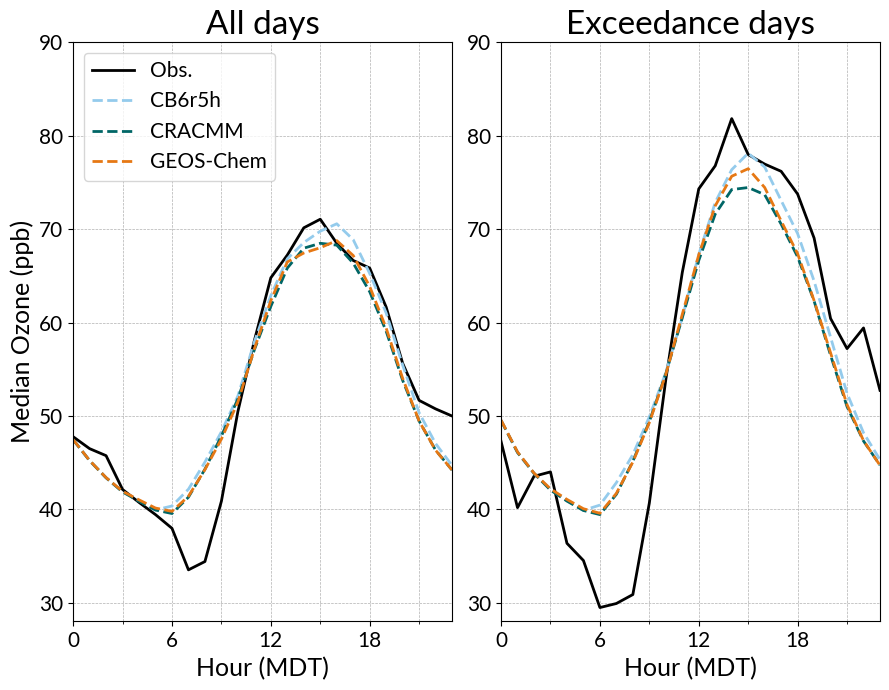

In [25]:
df_CB6r5h_hrly_species_conc['hour'] = df_CB6r5h_hrly_species_conc.index.hour
df_CRACMM_hrly_species_conc['hour'] = df_CRACMM_hrly_species_conc.index.hour
df_GEOSChem_hrly_species_conc['hour'] = df_GEOSChem_hrly_species_conc.index.hour
#df_MCM_hrly_species_conc['hour'] = df_MCM_hrly_species_conc.index.hour

#Median for valid campaign days (2024-07-19 to 2024-08-12)
df_CB6r5h_hourly_medians_species_conc = df_CB6r5h_hrly_species_conc.groupby('hour').median()
df_CRACMM_hourly_medians_species_conc = df_CRACMM_hrly_species_conc.groupby('hour').median()
df_GEOSChem_hourly_medians_species_conc = df_GEOSChem_hrly_species_conc.groupby('hour').median()

exceedance_date_list = voc_available_days_dict['Exceedance_days']

df_filtered_CB6r5h_hrly_species_conc = df_CB6r5h_hrly_species_conc[df_CB6r5h_hrly_species_conc.index.floor('D').isin(exceedance_date_list)]
df_filtered_CRACMM_hrly_species_conc = df_CRACMM_hrly_species_conc[df_CRACMM_hrly_species_conc.index.floor('D').isin(exceedance_date_list)]
df_filtered_GEOSChem_hrly_species_conc = df_GEOSChem_hrly_species_conc[df_GEOSChem_hrly_species_conc.index.floor('D').isin(exceedance_date_list)]

df_filtered_CB6r5h_hrly_species_conc['hour'] = df_filtered_CB6r5h_hrly_species_conc.index.hour
df_filtered_CRACMM_hrly_species_conc['hour'] = df_filtered_CRACMM_hrly_species_conc.index.hour
df_filtered_GEOSChem_hrly_species_conc['hour'] = df_filtered_GEOSChem_hrly_species_conc.index.hour

#Median for exceedance days
df_filtered_CB6r5h_hourly_medians_species_conc = df_filtered_CB6r5h_hrly_species_conc.groupby('hour').median()
df_filtered_CRACMM_hourly_medians_species_conc = df_filtered_CRACMM_hrly_species_conc.groupby('hour').median()
df_filtered_GEOSChem_hourly_medians_species_conc = df_filtered_GEOSChem_hrly_species_conc.groupby('hour').median()

# #df_MCM_hourly_medians_species_conc = df_MCM_hrly_species_conc.groupby('hour').mean()

fig, (ax1, ax2) = plt.subplots(1,2, figsize = (9,7), tight_layout=True)

ax1.plot(hour_range, df_CB6r5h_hourly_medians_species_conc['O3Initconc'], label = 'Obs.', linestyle = 'solid', linewidth = 2, color = 'k')
# obs_percentile_25_ozone=df_CB6r5h_hrly_species_conc.groupby('hour')['O3Initconc'].quantile(0.25)
# obs_percentile_75_ozone=df_CB6r5h_hrly_species_conc.groupby('hour')['O3Initconc'].quantile(0.75)
# ax1.fill_between(hour_range, obs_percentile_25_ozone.values, obs_percentile_75_ozone.values,  facecolor = 'gray', alpha = 0.2)
# print(obs_percentile_25_ozone.values)


ax1.plot(hour_range, df_CB6r5h_hourly_medians_species_conc['O3conc'], label = 'CB6r5h', linestyle = 'dashed', linewidth = 2, color = four_colorset1[0].tolist())
# CB6r5h_percentile_25_ozone=df_CB6r5h_hrly_species_conc.groupby('hour')['O3conc'].quantile(0.25)
# CB6r5h_percentile_75_ozone=df_CB6r5h_hrly_species_conc.groupby('hour')['O3conc'].quantile(0.75)
# ax1.fill_between(hour_range, CB6r5h_percentile_25_ozone.values, CB6r5h_percentile_75_ozone.values,  facecolor = four_colorset1[0].tolist(), alpha = 0.2)

ax1.plot(hour_range, df_CRACMM_hourly_medians_species_conc['O3conc'], label = 'CRACMM', linestyle = 'dashed', linewidth = 2, color = four_colorset1[1].tolist())
# CRACMM_percentile_25_ozone=df_CRACMM_hrly_species_conc.groupby('hour')['O3conc'].quantile(0.25)
# CRACMM_percentile_75_ozone=df_CRACMM_hrly_species_conc.groupby('hour')['O3conc'].quantile(0.75)
# ax1.fill_between(hour_range, CRACMM_percentile_25_ozone.values, CB6r5h_percentile_75_ozone.values,  facecolor = four_colorset1[0].tolist(), alpha = 0.2)

ax1.plot(hour_range, df_GEOSChem_hourly_medians_species_conc['O3conc'], label = 'GEOS-Chem', linestyle = 'dashed', linewidth = 2, color = four_colorset1[2].tolist())
ax1.set_title('All days')
ax1.set_ylabel('Median Ozone (ppb)')
ax1.set_ylim([28, 90])
ax1.set_xlabel('Hour (MDT)')
ax1.legend(loc='upper left')

ax1.xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 3, 6, 9, 12, 15, 18, 21]))
ax1.xaxis.set_minor_locator(MultipleLocator(3))
ax1.xaxis.set_major_locator(MultipleLocator(6))

ax2.plot(hour_range, df_filtered_CB6r5h_hourly_medians_species_conc['O3Initconc'], label = 'Obs.', linestyle = 'solid', linewidth = 2, color = 'k')
ax2.plot(hour_range, df_filtered_CB6r5h_hourly_medians_species_conc['O3conc'], label = 'CB6r5h', linestyle = 'dashed', linewidth = 2, color = four_colorset1[0].tolist())
ax2.plot(hour_range, df_filtered_CRACMM_hourly_medians_species_conc['O3conc'], label = 'CRACMM', linestyle = 'dashed', linewidth = 2, color = four_colorset1[1].tolist())
ax2.plot(hour_range, df_filtered_GEOSChem_hourly_medians_species_conc['O3conc'], label = 'GEOS-Chem', linestyle = 'dashed', linewidth = 2, color = four_colorset1[2].tolist())
ax2.set_title('Exceedance days')
ax2.xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 3, 6, 9, 12, 15, 18, 21]))
ax2.xaxis.set_minor_locator(MultipleLocator(3))
ax2.xaxis.set_major_locator(MultipleLocator(6))
ax2.set_ylim([28, 90])

ax2.set_xlabel('Hour (MDT)')
plt.xticks(np.arange(0,24,6))

ax1.grid(which='both', linestyle='--', linewidth=0.5)
ax2.grid(which='both', linestyle='--', linewidth=0.5)

plt.margins(x=0)


# plt.legend()
# #plt.title('Hourly Mean Ozone Between \n Chemical Mechanisms \nfor Exceedance Days\n')
plt.savefig(dirpath + '/F0AM_run_analysis/plots/ozone_conc_median_mechanism_hourly_comparison_exceedance_days_and_avg.png', dpi =150)
plt.savefig(dirpath + '/UDAQ_reports/2026_q1/plots/ozone_conc_median_mechanism_hourly_comparison_exceedance_days_and_avg.png', dpi =150)
plt.show()

/tmp/ipykernel_2181799/2348258490.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_CB6r5h_hrly_species_conc['hour'] = df_filtered_CB6r5h_hrly_species_conc.index.hour
/tmp/ipykernel_2181799/2348258490.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_CRACMM_hrly_species_conc['hour'] = df_filtered_CRACMM_hrly_species_conc.index.hour
/tmp/ipykernel_2181799/2348258490.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[

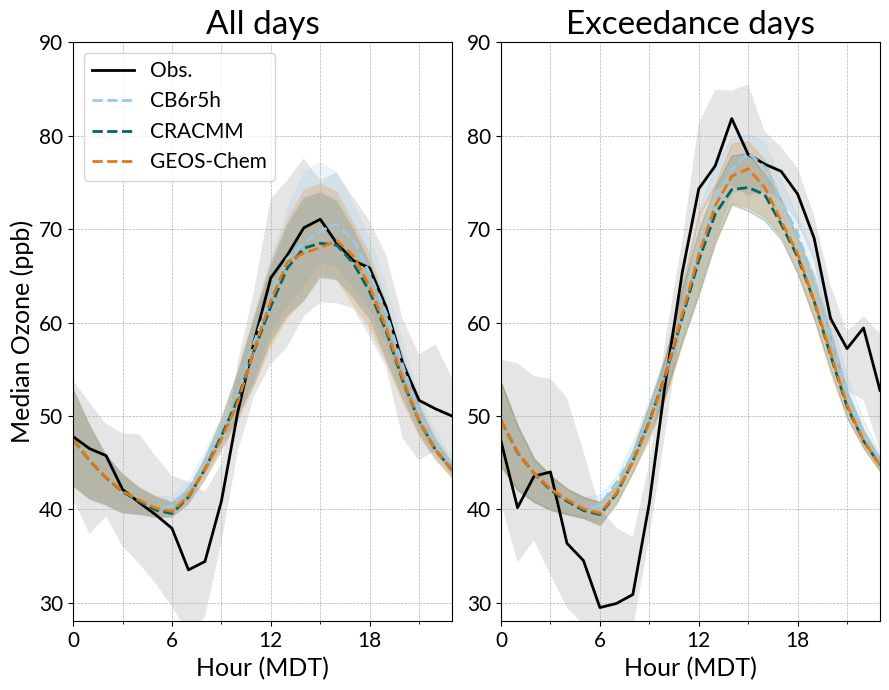

In [26]:
df_CB6r5h_hrly_species_conc['hour'] = df_CB6r5h_hrly_species_conc.index.hour
df_CRACMM_hrly_species_conc['hour'] = df_CRACMM_hrly_species_conc.index.hour
df_GEOSChem_hrly_species_conc['hour'] = df_GEOSChem_hrly_species_conc.index.hour
#df_MCM_hrly_species_conc['hour'] = df_MCM_hrly_species_conc.index.hour

#Median for valid campaign days (2024-07-19 to 2024-08-12)
df_CB6r5h_hourly_medians_species_conc = df_CB6r5h_hrly_species_conc.groupby('hour').median()
df_CRACMM_hourly_medians_species_conc = df_CRACMM_hrly_species_conc.groupby('hour').median()
df_GEOSChem_hourly_medians_species_conc = df_GEOSChem_hrly_species_conc.groupby('hour').median()

exceedance_date_list = voc_available_days_dict['Exceedance_days']

df_filtered_CB6r5h_hrly_species_conc = df_CB6r5h_hrly_species_conc[df_CB6r5h_hrly_species_conc.index.floor('D').isin(exceedance_date_list)]
df_filtered_CRACMM_hrly_species_conc = df_CRACMM_hrly_species_conc[df_CRACMM_hrly_species_conc.index.floor('D').isin(exceedance_date_list)]
df_filtered_GEOSChem_hrly_species_conc = df_GEOSChem_hrly_species_conc[df_GEOSChem_hrly_species_conc.index.floor('D').isin(exceedance_date_list)]

df_filtered_CB6r5h_hrly_species_conc['hour'] = df_filtered_CB6r5h_hrly_species_conc.index.hour
df_filtered_CRACMM_hrly_species_conc['hour'] = df_filtered_CRACMM_hrly_species_conc.index.hour
df_filtered_GEOSChem_hrly_species_conc['hour'] = df_filtered_GEOSChem_hrly_species_conc.index.hour

#Median for exceedance days
df_filtered_CB6r5h_hourly_medians_species_conc = df_filtered_CB6r5h_hrly_species_conc.groupby('hour').median()
df_filtered_CRACMM_hourly_medians_species_conc = df_filtered_CRACMM_hrly_species_conc.groupby('hour').median()
df_filtered_GEOSChem_hourly_medians_species_conc = df_filtered_GEOSChem_hrly_species_conc.groupby('hour').median()

# #df_MCM_hourly_medians_species_conc = df_MCM_hrly_species_conc.groupby('hour').mean()

fig, (ax1, ax2) = plt.subplots(1,2, figsize = (9,7), tight_layout=True)

ax1.plot(hour_range, df_CB6r5h_hourly_medians_species_conc['O3Initconc'], label = 'Obs.', linestyle = 'solid', linewidth = 2, color = 'k')
obs_percentile_25_ozone=df_CB6r5h_hrly_species_conc.groupby('hour')['O3Initconc'].quantile(0.25)
obs_percentile_75_ozone=df_CB6r5h_hrly_species_conc.groupby('hour')['O3Initconc'].quantile(0.75)
ax1.fill_between(hour_range, obs_percentile_25_ozone.values, obs_percentile_75_ozone.values,  facecolor = 'gray', alpha = 0.2)

ax1.plot(hour_range, df_CB6r5h_hourly_medians_species_conc['O3conc'], label = 'CB6r5h', linestyle = 'dashed', linewidth = 2, color = four_colorset1[0].tolist())
CB6r5h_percentile_25_ozone=df_CB6r5h_hrly_species_conc.groupby('hour')['O3conc'].quantile(0.25)
CB6r5h_percentile_75_ozone=df_CB6r5h_hrly_species_conc.groupby('hour')['O3conc'].quantile(0.75)
ax1.fill_between(hour_range, CB6r5h_percentile_25_ozone.values, CB6r5h_percentile_75_ozone.values,  facecolor = four_colorset1[0].tolist(), alpha = 0.2)

ax1.plot(hour_range, df_CRACMM_hourly_medians_species_conc['O3conc'], label = 'CRACMM', linestyle = 'dashed', linewidth = 2, color = four_colorset1[1].tolist())
CRACMM_percentile_25_ozone=df_CRACMM_hrly_species_conc.groupby('hour')['O3conc'].quantile(0.25)
CRACMM_percentile_75_ozone=df_CRACMM_hrly_species_conc.groupby('hour')['O3conc'].quantile(0.75)
ax1.fill_between(hour_range, CRACMM_percentile_25_ozone.values, CRACMM_percentile_75_ozone.values,  facecolor = four_colorset1[1].tolist(), alpha = 0.2)

ax1.plot(hour_range, df_GEOSChem_hourly_medians_species_conc['O3conc'], label = 'GEOS-Chem', linestyle = 'dashed', linewidth = 2, color = four_colorset1[2].tolist())
GEOSChem_percentile_25_ozone=df_GEOSChem_hrly_species_conc.groupby('hour')['O3conc'].quantile(0.25)
GEOSChem_percentile_75_ozone=df_GEOSChem_hrly_species_conc.groupby('hour')['O3conc'].quantile(0.75)
ax1.fill_between(hour_range, GEOSChem_percentile_25_ozone.values, GEOSChem_percentile_75_ozone.values,  facecolor = four_colorset1[2].tolist(), alpha = 0.2)

ax1.set_title('All days')
ax1.set_ylabel('Median Ozone (ppb)')
ax1.set_ylim([28, 90])
ax1.set_xlabel('Hour (MDT)')
ax1.legend(loc='upper left')

ax1.xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 3, 6, 9, 12, 15, 18, 21]))
ax1.xaxis.set_minor_locator(MultipleLocator(3))
ax1.xaxis.set_major_locator(MultipleLocator(6))

ax2.plot(hour_range, df_filtered_CB6r5h_hourly_medians_species_conc['O3Initconc'], label = 'Obs.', linestyle = 'solid', linewidth = 2, color = 'k')
obs_filtered_percentile_25_ozone=df_filtered_CB6r5h_hrly_species_conc.groupby('hour')['O3Initconc'].quantile(0.25)
obs_filtered_percentile_75_ozone=df_filtered_CB6r5h_hrly_species_conc.groupby('hour')['O3Initconc'].quantile(0.75)
ax2.fill_between(hour_range, obs_filtered_percentile_25_ozone.values, obs_filtered_percentile_75_ozone.values,  facecolor = 'gray', alpha = 0.2)

ax2.plot(hour_range, df_filtered_CB6r5h_hourly_medians_species_conc['O3conc'], label = 'CB6r5h', linestyle = 'dashed', linewidth = 2, color = four_colorset1[0].tolist())
CB6r5h_filtered_percentile_25_ozone=df_filtered_CB6r5h_hrly_species_conc.groupby('hour')['O3conc'].quantile(0.25)
CB6r5h_filtered_percentile_75_ozone=df_filtered_CB6r5h_hrly_species_conc.groupby('hour')['O3conc'].quantile(0.75)
ax2.fill_between(hour_range, CB6r5h_filtered_percentile_25_ozone.values, CB6r5h_filtered_percentile_75_ozone.values, color = four_colorset1[0].tolist(), alpha = 0.2)

ax2.plot(hour_range, df_filtered_CRACMM_hourly_medians_species_conc['O3conc'], label = 'CRACMM', linestyle = 'dashed', linewidth = 2, color = four_colorset1[1].tolist())
CRACMM_filtered_percentile_25_ozone=df_filtered_CRACMM_hrly_species_conc.groupby('hour')['O3conc'].quantile(0.25)
CRACMM_filtered_percentile_75_ozone=df_filtered_CRACMM_hrly_species_conc.groupby('hour')['O3conc'].quantile(0.75)
ax2.fill_between(hour_range, CRACMM_filtered_percentile_25_ozone.values, CRACMM_filtered_percentile_75_ozone.values, color = four_colorset1[1].tolist(), alpha = 0.2)

ax2.plot(hour_range, df_filtered_GEOSChem_hourly_medians_species_conc['O3conc'], label = 'GEOS-Chem', linestyle = 'dashed', linewidth = 2, color = four_colorset1[2].tolist())
GEOSChem_filtered_percentile_25_ozone=df_filtered_GEOSChem_hrly_species_conc.groupby('hour')['O3conc'].quantile(0.25)
GEOSChem_filtered_percentile_75_ozone=df_filtered_GEOSChem_hrly_species_conc.groupby('hour')['O3conc'].quantile(0.75)
ax2.fill_between(hour_range, GEOSChem_filtered_percentile_25_ozone.values, GEOSChem_filtered_percentile_75_ozone.values, color = four_colorset1[2].tolist(), alpha = 0.2)

ax2.set_title('Exceedance days')
ax2.xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 3, 6, 9, 12, 15, 18, 21]))
ax2.xaxis.set_minor_locator(MultipleLocator(3))
ax2.xaxis.set_major_locator(MultipleLocator(6))
ax2.set_ylim([28, 90])

ax2.set_xlabel('Hour (MDT)')
plt.xticks(np.arange(0,24,6))

ax1.grid(which='both', linestyle='--', linewidth=0.5)
ax2.grid(which='both', linestyle='--', linewidth=0.5)

plt.margins(x=0)


# plt.legend()
# #plt.title('Hourly Mean Ozone Between \n Chemical Mechanisms \nfor Exceedance Days\n')
plt.savefig(dirpath + '/F0AM_run_analysis/plots/ozone_conc_median_mechanism_hourly_comparison_exceedance_days_and_avg_with_quartiles.png', dpi =150)
plt.savefig(dirpath + '/UDAQ_reports/2026_q1/plots/ozone_conc_median_mechanism_hourly_comparison_exceedance_days_and_avg_with_quartiles.png', dpi =150)
plt.show()

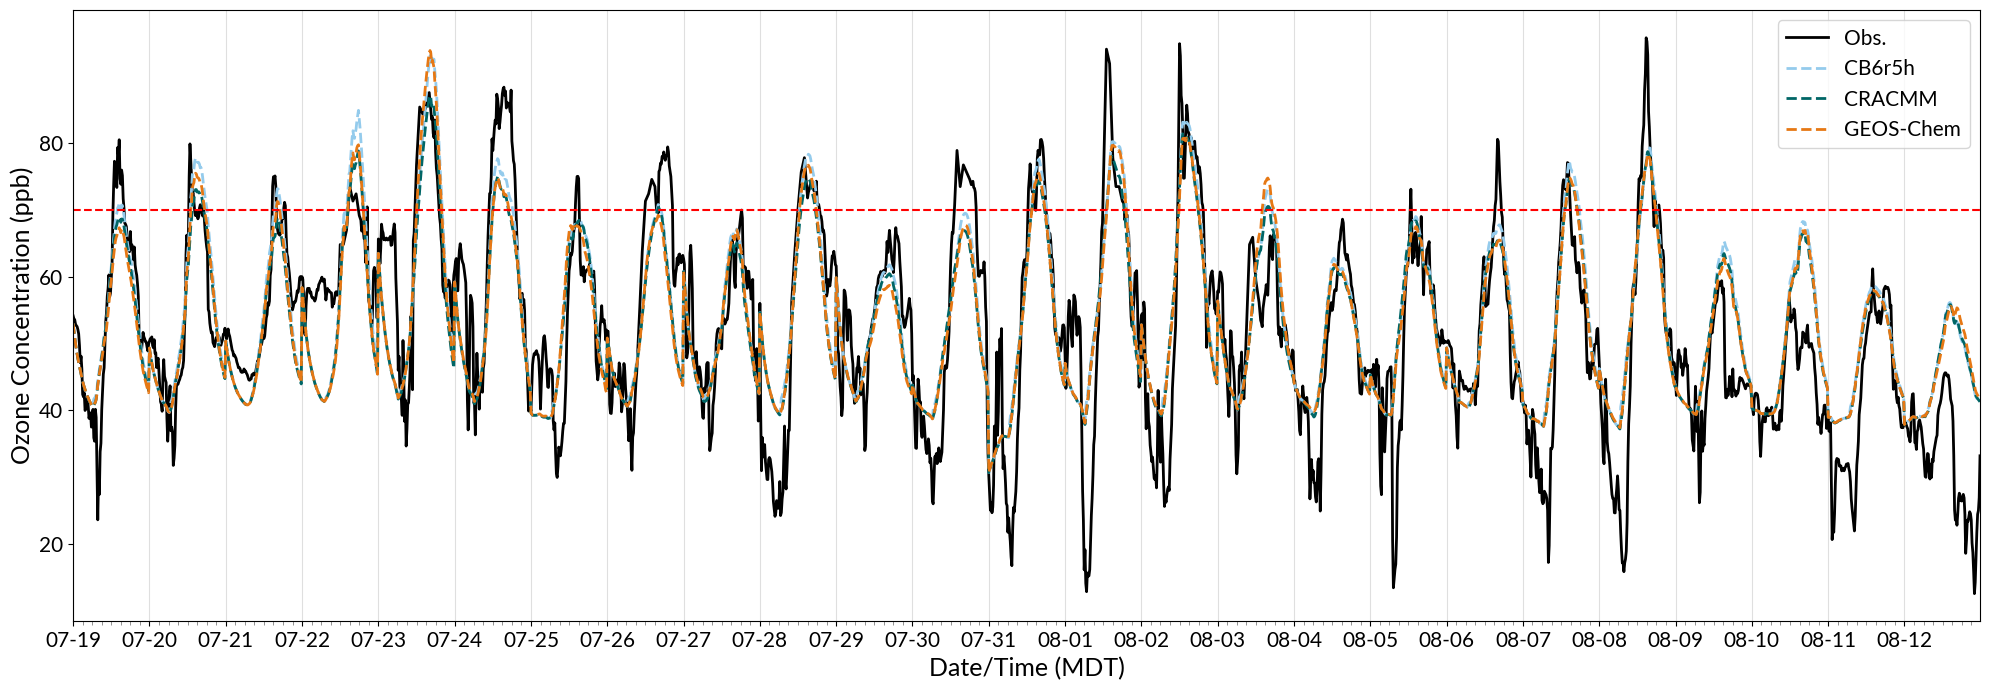

In [29]:
fig, ax = plt.subplots(figsize = (20,7), layout = 'tight')
plt.rcParams['figure.figsize'] = [1.618 * i for i in plt.rcParams['figure.figsize']]

plt.plot(new_index, df_CB6r5h_species_conc['O3Initconc'], label = 'Obs.', linestyle = 'solid', linewidth = 2, color = 'black')
plt.plot(new_index, df_CB6r5h_species_conc['O3conc'], label = 'CB6r5h', linestyle = 'dashed', linewidth = 2, color = four_colorset1[0].tolist())
plt.plot(new_index,df_CRACMM_species_conc['O3conc'], label = 'CRACMM', linestyle = 'dashed', linewidth = 2, color = four_colorset1[1].tolist())
plt.plot(new_index,df_GEOSChem_species_conc['O3conc'], label = 'GEOS-Chem', linestyle = 'dashed', linewidth = 2, color = four_colorset1[2].tolist())
# plt.plot(new_index,df_MCM_species_conc['O3conc'], label = 'MCM', linestyle = 'dashed', linewidth = 2, color = four_colorset1[3].tolist())
ax.hlines(y=70, xmin = df_CB6r5h_species_conc.index[0], xmax = df_CB6r5h_species_conc.index[len(df_CB6r5h_species_conc.index)-1], linestyle = 'dashed', color = 'r')

tz_mdt = df_CB6r5h_species_conc.index.tz
ax.xaxis.set_major_locator(mdates.DayLocator(tz = tz_mdt))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d', tz = tz_mdt))
# Minor ticks: every 3 hours
ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 3, 6, 9, 12, 15, 18, 21], tz = tz_mdt))
# Rotate and format tick labels
ax.tick_params(axis='x', which='major')
ax.tick_params(axis='x', which='minor', length=3, color='gray')
ax.grid(which='major', axis = 'x', alpha = 0.4)

plt.xlabel('Date/Time (MDT)')
# plt.xticks(np.arange(0,24))
plt.margins(x=0)

plt.ylabel('Ozone Concentration (ppb)')
plt.legend()
#plt.title('Ozone Between Chemical Mechanisms \nfor July 19, 2024\n')
plt.savefig(dirpath + '/F0AM_run_analysis/plots/ozone_conc_mechanism_comparison_timeseries_07192024_08122024.png', dpi =150)
plt.savefig(dirpath + '/UDAQ_reports/2026_q1/plots/ozone_conc_mechanism_comparison_timeseries_07192024_08122024.png', dpi =150)
plt.show()

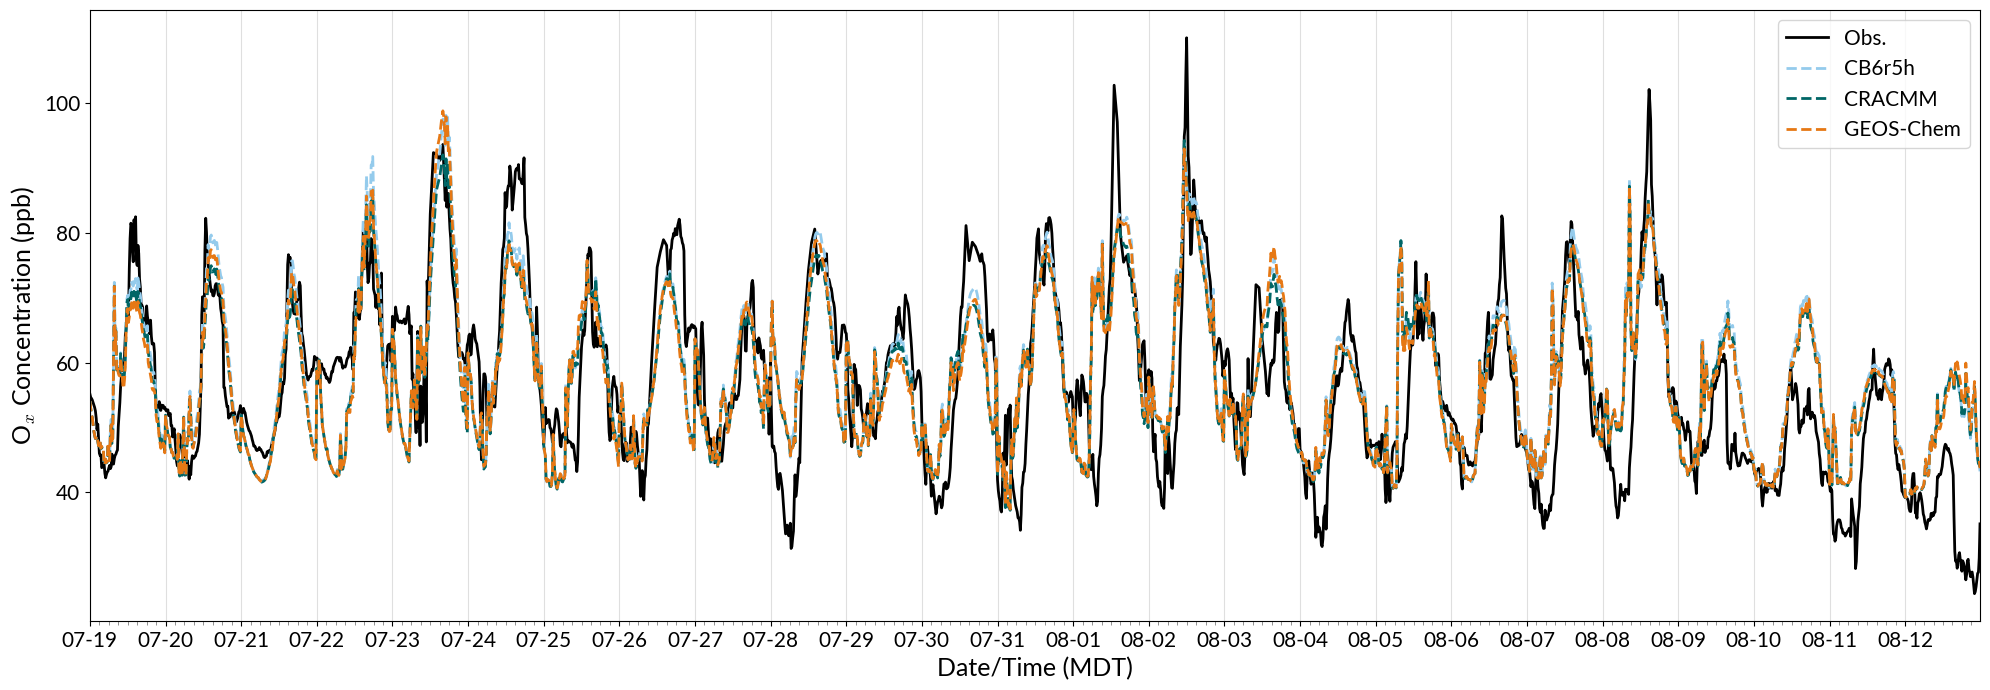

In [30]:
fig, ax = plt.subplots(figsize = (20,7), layout = 'tight')
plt.rcParams['figure.figsize'] = [1.618 * i for i in plt.rcParams['figure.figsize']]

plt.plot(new_index, df_CB6r5h_species_conc['O3Initconc']+df_CB6r5h_species_conc['NO2Initconc']+2*df_CB6r5h_species_conc['NO3Initconc']+3*df_CB6r5h_species_conc['N2O5Initconc'], label = 'Obs.', linestyle = 'solid', linewidth = 2, color = 'black')
plt.plot(new_index, df_CB6r5h_species_conc['O3conc']+df_CB6r5h_species_conc['NO2conc']+2*df_CB6r5h_species_conc['NO3conc']+3*df_CB6r5h_species_conc['N2O5conc'], label = 'CB6r5h', linestyle = 'dashed', linewidth = 2, color = four_colorset1[0].tolist())
plt.plot(new_index, df_CRACMM_species_conc['O3conc']+df_CRACMM_species_conc['NO2conc']+2*df_CRACMM_species_conc['NO3conc']+3*df_CRACMM_species_conc['N2O5conc'], label = 'CRACMM', linestyle = 'dashed', linewidth = 2, color = four_colorset1[1].tolist())
plt.plot(new_index, df_GEOSChem_species_conc['O3conc']+df_GEOSChem_species_conc['NO2conc']+2*df_GEOSChem_species_conc['NO3conc']+3*df_GEOSChem_species_conc['N2O5conc'], label = 'GEOS-Chem', linestyle = 'dashed', linewidth = 2, color = four_colorset1[2].tolist())
# plt.plot(new_index, df_MCM_species_conc['O3conc']+df_MCM_species_conc['NO2conc'], label = 'MCM', linestyle = 'dashed', linewidth = 2, color = four_colorset1[3].tolist())

tz_mdt = df_CB6r5h_species_conc.index.tz
ax.xaxis.set_major_locator(mdates.DayLocator(tz = tz_mdt))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d', tz = tz_mdt))
# Minor ticks: every 3 hours
ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 3, 6, 9, 12, 15, 18, 21], tz = tz_mdt))
# Rotate and format tick labels
ax.tick_params(axis='x', which='major')
ax.tick_params(axis='x', which='minor', length=3, color='gray')
ax.grid(which='major', axis = 'x', alpha = 0.4)

plt.xlabel('Date/Time (MDT)')
# plt.xticks(np.arange(0,24))
plt.margins(x=0)


plt.ylabel('O$_x$ Concentration (ppb)')
plt.legend()
#plt.title('Ozone Between Chemical Mechanisms \nfor July 19, 2024\n')
plt.savefig(dirpath + '/F0AM_run_analysis/plots/ox_conc_mechanism_comparison_timeseries_07192024_08122024.png', dpi =150)
plt.savefig(dirpath + '/UDAQ_reports/2026_q1/plots/ox_conc_mechanism_comparison_timeseries_07192024_08122024.png', dpi =150)
plt.show()